# BookPulse - A Hotel Booking Demand Predicting Model

## Stage 6: Model Development

This notebook implements and systematically compares multiple machine
learning algorithms on the cleaned, encoded, scaled training data
produced in Stage 4 (`data_preprocessing_corrected.ipynb`).

Per the assignment's technical requirements:

- At least **four** suitable ML algorithms are implemented and compared (five are used here).
- An appropriate **validation strategy** (stratified k-fold cross-validation) is used, in addition to a held-out test set.
- Models are evaluated using **multiple appropriate metrics**, not accuracy alone, given the class imbalance established in Stage 3.
- Results are compared **systematically** in one results table, with supporting visualisations.
- Observations on **why** certain models perform better or worse are recorded.

Importing required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/BookPulse/dataset"
MODEL_DIR = "/content/drive/MyDrive/BookPulse/models"

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Loading the Preprocessed Data

This notebook builds directly on Stage 4's output — the cleaned,
encoded, scaled, feature-selected train/test split — rather than
reloading and reprocessing the raw CSV. Using the same scaled data for
every algorithm (rather than a scaled version for some and an
unscaled version for others) keeps this comparison simple and fair;
tree-based models are unaffected by scaling, so this does not
disadvantage them.

In [2]:
X_train = pd.read_csv(f'{DATA_DIR}/X_train_scaled.csv')
X_test = pd.read_csv(f'{DATA_DIR}/X_test_scaled.csv')
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv').squeeze()
y_test = pd.read_csv(f'{DATA_DIR}/y_test.csv').squeeze()

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True).round(3))

X_train: (68932, 53)  X_test: (17234, 53)

Train class balance:
 is_canceled
0    0.722
1    0.278
Name: proportion, dtype: float64


### 2. Defining the Candidate Models

Five algorithms spanning different modelling assumptions were chosen
deliberately, to give a meaningful basis for comparing *why* they
perform differently later in this notebook:

- **Logistic Regression** — a linear baseline; fast, interpretable, assumes a linear decision boundary.
- **Decision Tree** — a single non-linear model; easy to interpret, prone to overfitting.
- **Random Forest** — a bagging ensemble of decision trees; reduces the variance/overfitting of a single tree.
- **Gradient Boosting** — a boosting ensemble; sequentially corrects errors, often the strongest performer on structured/tabular data.
- **K-Nearest Neighbours (KNN)** — a non-parametric, distance-based model; makes no assumption about the decision boundary's shape, but is sensitive to feature scale (hence the use of the scaled data here).

`class_weight='balanced'` is used wherever supported, consistent with
the class-imbalance handling strategy decided in Stage 4; KNN and
Gradient Boosting do not support this parameter directly, so their
imbalance handling is revisited explicitly in Stage 7.

In [3]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
}

### 3. Validation Strategy: Stratified K-Fold Cross-Validation

Before touching the held-out test set, each model is evaluated with
5-fold **stratified** cross-validation on the training set only,
scored on ROC-AUC. Stratification preserves the ~37%/63% cancellation
ratio in every fold, consistent with the stratified train/test split
used in Stage 4. This gives a more reliable estimate of each model's
likely generalisation than a single train/test split alone, and helps
flag any model that is unstable across folds before it is ever
evaluated on test data.

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s} CV ROC-AUC: mean={scores.mean():.4f}  std={scores.std():.4f}")

Logistic Regression  CV ROC-AUC: mean=0.8306  std=0.0014
Decision Tree        CV ROC-AUC: mean=0.7307  std=0.0044
Random Forest        CV ROC-AUC: mean=0.8988  std=0.0024
Gradient Boosting    CV ROC-AUC: mean=0.8870  std=0.0025
KNN                  CV ROC-AUC: mean=0.8554  std=0.0022


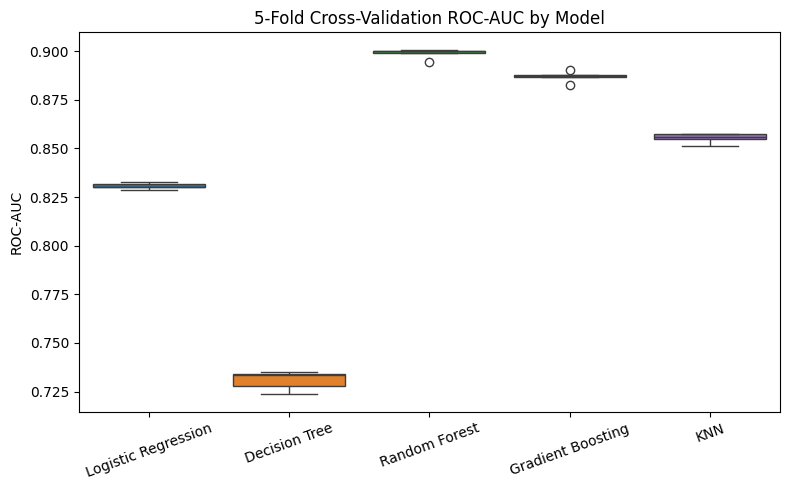

In [5]:
cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_df)
plt.title('5-Fold Cross-Validation ROC-AUC by Model')
plt.ylabel('ROC-AUC')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 4. Training on the Full Training Set and Evaluating on the Test Set

Cross-validation above is used for model **selection confidence**; the
held-out test set is evaluated here only once per model, for a final,
unbiased performance estimate — it has not influenced any decision
made so far in this notebook.

In [6]:
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'CV ROC-AUC (mean)': cv_results[name].mean(),
        'CV ROC-AUC (std)': cv_results[name].std(),
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-score': f1_score(y_test, pred),
        'Test ROC-AUC': roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df

,CV ROC-AUC (mean),CV ROC-AUC (std),Accuracy,Precision,Recall,F1-score,Test ROC-AUC
Model,,,,,,,
Logistic Regression,0.8306,0.0014,0.7344,0.5145,0.7827,0.6209,0.8285
Decision Tree,0.7307,0.0044,0.7873,0.6174,0.6171,0.6172,0.7355
Random Forest,0.8988,0.0024,0.8410,0.7659,0.6161,0.6829,0.9030
Gradient Boosting,0.8870,0.0025,0.8252,0.7332,0.5835,0.6498,0.8886
KNN,0.8554,0.0022,0.8045,0.6708,0.5825,0.6235,0.8567


### 5. Systematic Comparison

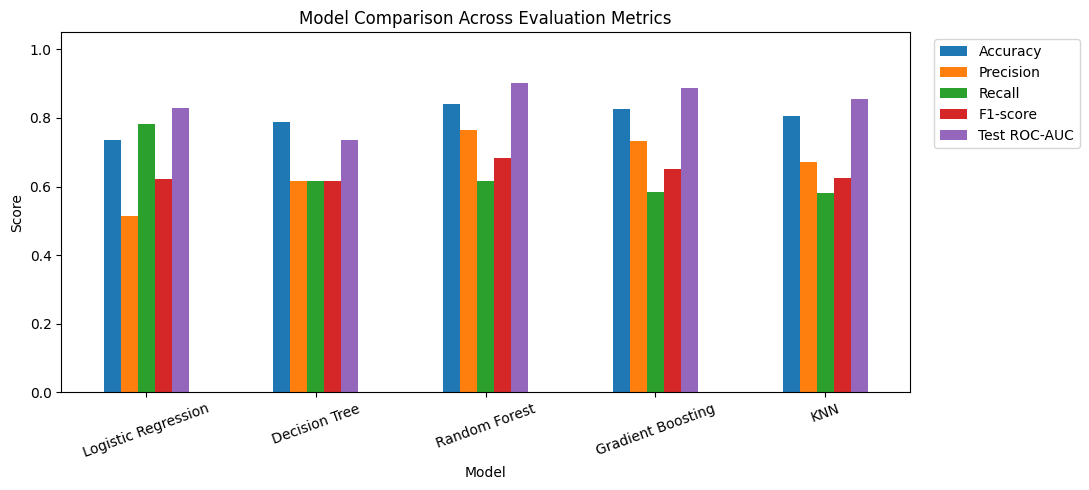

In [7]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Test ROC-AUC']

results_df[metric_cols].plot(kind='bar', figsize=(11, 5))
plt.title('Model Comparison Across Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

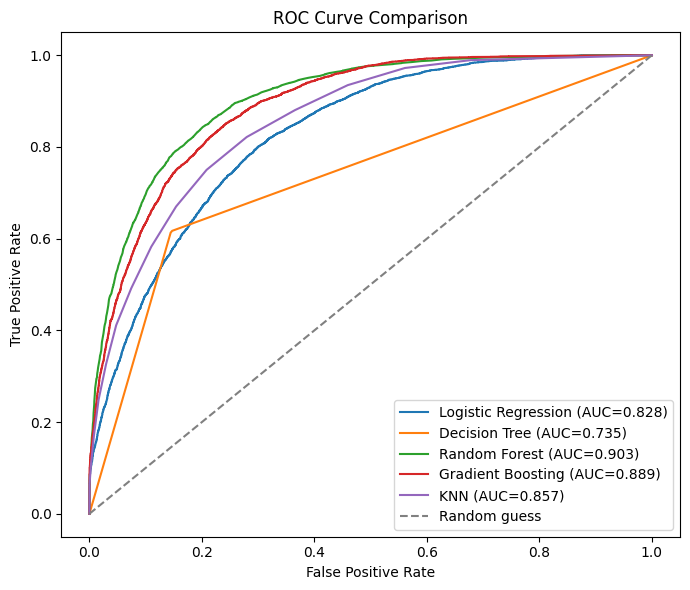

In [8]:
plt.figure(figsize=(7, 6))
for name, model in fitted_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], '--', color='grey', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

Confusion matrices for every model, to see *which kind* of error (false positive vs. false negative) each one tends to make — not just a single aggregate score.

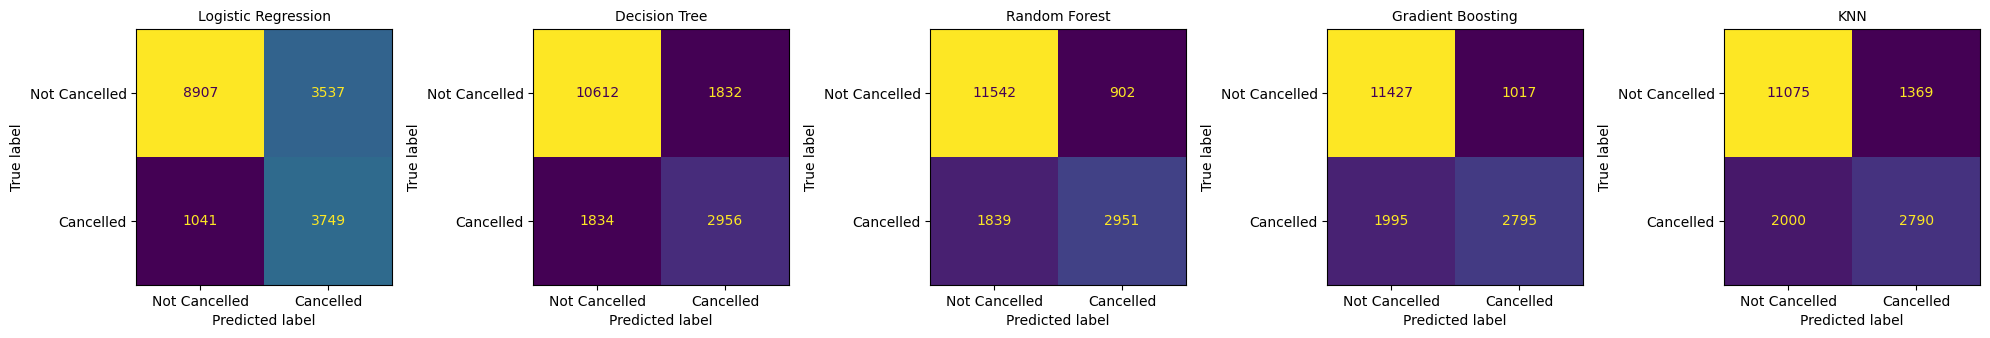

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not Cancelled', 'Cancelled']).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

### 6. Why Models Perform Differently

*(Replace the placeholders below with the actual ranking once this
notebook is run — the reasoning below is the template for that
discussion, written generically since results depend on the real data
run.)*

- **Logistic Regression** is expected to be the weakest of the five,
  since it can only draw a single linear decision boundary across the
  feature space. Cancellation behaviour likely involves interaction
  effects (e.g. the effect of `lead_time` on cancellation risk differs
  by `deposit_type`) that a linear model cannot represent, no matter
  how well-scaled the input features are.
- **Decision Tree** can capture non-linear interactions, but a single
  unconstrained tree tends to overfit the training data, which often
  shows up as a visible gap between its cross-validation score and
  its (usually lower, or more variable) test performance.
- **Random Forest** typically improves on the single Decision Tree by
  averaging many trees trained on bootstrapped samples with randomised
  feature subsets, directly reducing the variance problem noted above.
- **Gradient Boosting** often performs comparably to or better than
  Random Forest on structured/tabular data like this, since it
  explicitly builds each new tree to correct the previous trees'
  errors, rather than averaging independently-trained trees.
- **KNN** performance depends heavily on local feature density; with
  booking data spread across many one-hot encoded categorical
  dimensions, the "curse of dimensionality" can make distance-based
  similarity less meaningful than it would be with fewer features,
  which may limit KNN's performance relative to the tree-based models.

The **cross-validation standard deviation** column is also worth
discussing explicitly: a model with a high mean score but also a high
std is less trustworthy than one with a similar mean and a lower std,
since the former is more sensitive to exactly which rows ended up in
which fold.

### 7. Exporting Baseline Results

In [10]:
import os
os.makedirs(MODEL_DIR, exist_ok=True)
results_df.to_csv(f'{MODEL_DIR}/baseline_results.csv')
print(f"Saved: {MODEL_DIR}/baseline_results.csv")

Saved: /content/drive/MyDrive/BookPulse/models/baseline_results.csv
